In [ ]:
## Day 23
# Hour 1


hi


What is ROC Curve?
ROC = Receiver Operating Characteristic curve
It shows:
Model performance across ALL thresholds

Axes of ROC curve
x -axis - FPR - false postive rate
- out of all actual neagtive how many were falsly predicted as positive
FPR - FP/(FP+TN)

y-axis - True postive rate - 
- out of all actual positive how many were actual predicted positive
TPR - TP/(TP+FN)

ROC shows trade-off between catching positives and making false alarms

High threshold (strict)
Few positives
FP ↓ → FPR ↓
TP ↓ → TPR ↓

👉 Point near (0,0)


Low threshold (lenient)
Many positives
FP ↑ → FPR ↑
TP ↑ → TPR ↑

👉 Point near (1,1)

ROC evaluates model independently of threshold

Why ROC is Powerful :-
Considers ALL thresholds
Shows overall model behavior
Helps compare models


ROC tells you:
“If I relax threshold, how much recall do I gain and how many false alarms I add?”

If curve ≈ diagonal → model is random ❌
If curve is above diagonal → useful ✔


ROC curve is used to evaluate model performance across all thresholds and to choose an optimal threshold based on the trade-off between TPR and FPR

In [3]:
y_true = [1,0,1,0]
# y_prob = [0.9,0.8,0.4,0.3]
from sklearn.metrics import confusion_matrix
# thresholds = [0.9,0.8,0.4,0.3]
# for i in thresholds:
#     y_pred = [1 if x>=i else 0 for x in y_prob]
#     cm = confusion_matrix(y_true, y_pred)
#     tn, fp, fn, tp = cm.ravel() 
#     print(f"Threshold:{i} y_pred:- {y_pred} TP: {tp} FP: {fp} FN: {fn} TN: {tn}")
#     print(f"TPR: {tp/(tp+fn)} FPR: {fp/(fp+tn)}")

y_pred = [1,1,1,1]
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel() 
print(f"TPR: {tp/(tp+fn)} FPR: {fp/(fp+tn)}")

y_pred = [0,0,0,0]
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel() 
print(f"TPR: {tp/(tp+fn)} FPR: {fp/(fp+tn)}")


TPR: 1.0 FPR: 1.0
TPR: 0.0 FPR: 0.0


In [ ]:
## Hour 2
# AUC


AUC (Area Under ROC Curve) — Notes
🧠 1. Definition
AUC = Area under the ROC curve
It measures:
How well a model separates positive and negative classes
2. Core Interpretation (MOST IMPORTANT)
AUC = Probability that a random positive is ranked higher than a random negative
Example
AUC = 0.990% chance:
positive score > negative score
 AUC Value Meaning
AUC	Interpretation
1.0	Perfect model
0.9+	Excellent
0.8	Good
0.7	Average
0.5	Random
<0.Worse than random
🔥 4.Key Properties
Threshold independent
Works across all thresholds
Ranking-based
Uses probability ordering, not classification
Single number summary
Compresses ROC into one value

5. Relationship with ROC
ROC → curve (TPR vs FPR)
AUC → area under that curve

6. Visual Meaning
Closer to top-left → better → higher AUC
Diagonal line → random → AUC = 0.5

7. When to Use AUC
✔ Model comparison
Choose better classifier

Imbalanced datasets
More reliable than accuracy
When threshold is not fixed

⚠️ 8. Limitations
❌ Does NOT tell:
Exact precision/recall
Best threshold
High AUC ≠ perfect model
Performance at chosen threshold may still be poor

9. Key Insight
AUC measures ranking ability, not classification accuracy

10. One-Line Summary (Interview)
“AUC measures how well a model ranks positive instances higher than negative ones.”

11. Quick Comparison
Metric	          Focus
Precision	       FP
Recall	           FN
F1	              Balance
AUC	         Ranking ability
🚀 12. Memory Trick
AUC = “Ability to Understand Classes”
Final Insight
ROC shows all possibilities → AUC summarizes them

Why probabilities?
- Because ROC evaluates performance across all thresholds, which requires probability scores rather than binary predictions.”
- roc_curve computes FPR and TPR for all possible thresholds.
- AUC measures how well a model ranks positive instances above negative ones.”

In [ ]:
# Hour 3
# Apply ROC and AUC curve 
from sklearn.metrics import roc_curve, auc

y_true = [1,0,1,0]
y_prob = [0.9,0.8,0.4,0.3]

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

print("FPR:", fpr)
print("TPR:", tpr)
print("Thresholds:", thresholds)
print("AUC:", roc_auc)

# ROC includes an extra threshold to represent the case where all 
# predictions are negative, giving the starting point (0,0), 
# hence one extra point.”

FPR: [0.  0.  0.5 0.5 1. ]
TPR: [0.  0.5 0.5 1.  1. ]
Thresholds: [inf 0.9 0.8 0.4 0.3]
AUC: 0.75


In [5]:
# with a model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

X = [[1],[2],[3],[4],[5],[6]]
y = [0,0,0,1,1,1]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

model = LogisticRegression()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 1.0


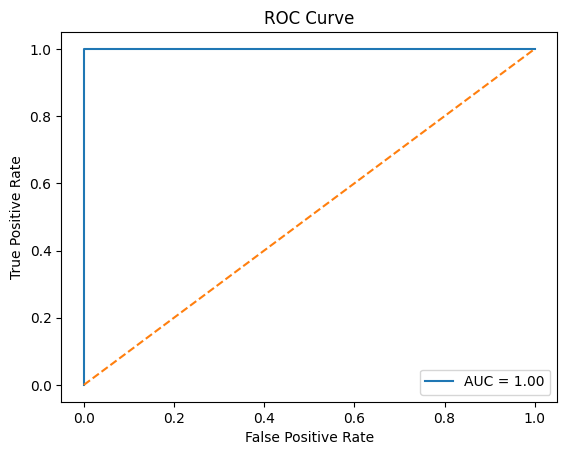

In [6]:
# Plot ROC curve
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [10]:
# Case 1
y_true = [1,1,1,0,0,0]
y_prob = [0.9,0.8,0.7,0.3,0.2,0.1]

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC:",roc_auc)

# CAse 2- random model
y_prob = [0.5,0.5,0.5,0.5,0.5,0.5]
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC:",roc_auc)

AUC: 1.0
AUC: 0.5


Notes on ROC and UAC
Perfect Model
Goes to (0,1) then flat
Best possible

Good Model
Curve bends toward top-left

✔ Random Model
Diagonal line
AUC = 0.5

❌ Bad Model
Curve below diagonal

Shape Meaning
Steep upward → captures positives early ✔
Flat → many false positives ❌

ROC shows all thresholds
Shape reflects class separation ability

ROC curve shape tells how well a model separates positives from negatives

ROC curve shape shows how quickly a model can capture positives while minimizing false positives

Best threshold
Precision/Recall at a specific threshold
Business cost impact

When ROC is useful
“When evaluating model performance across all thresholds and comparing models.”

When ROC is not enough
“When specific business decisions require precision, recall, or threshold tuning.

ROC helps:
“Visualize the trade-off between TPR and FPR across thresholds”

AUC tells how good the model is, but threshold decides how useful it is

Hour 6
1. Why Compare Models
Choose best model among multiple options

🎯 2. Using AUC
Higher AUC → better model (better ranking ability)

🔹 Rule
Same dataset → compare AUC directly
Higher AUC wins (generally)

3. Using ROC Curve
Compare curves:
Curve closer to top-left → better
Curve above another → better model

4. When AUC is Enough
✔ Comparing models globally
✔ Same data & conditions

⚠️ 5. When AUC is NOT Enough
❌ Business constraints
High AUC but high FP → bad for spam
❌ Threshold matters
AUC ignores threshold
Business uses one threshold

6. Key Insight
AUC compares models globally, but decisions are made locally (threshold)

7. Best Practice
Use both:
AUC → overall performance
Precision/Recall → threshold decision

8. Important Case
Same AUC ≠ same model

Different ROC shapes
Different behavior at thresholds
9. Decision Flow
Model → AUC → shortlist→ Threshold → final choice

10. One-Line Summary
Higher AUC means better model, but final selection depends on business needs

Memory Trick
“AUC chooses model, threshold chooses behavior”

In [17]:
# Hour 7
from sklearn.metrics import precision_score,recall_score

y_true = [1,0,1,1,0,0,1,0,1,0]

# Model A
y_prob_A = [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05]

fpr, tpr, thresholds = roc_curve(y_true, y_prob_A)
roc_auc = auc(fpr, tpr)
print("A_AUC:",roc_auc)

threshold = 0.5
y_pred_A = [1 if x>=threshold else 0 for x in y_prob_A]

cm = confusion_matrix(y_true,y_pred_A)
prec_A = precision_score(y_true,y_pred_A)
recall_A = recall_score(y_true,y_pred_A)
tn,fp,fn,tp = cm.ravel()
print("y_pred_A:",y_pred_A)
print(f"TN: {tn} FP: {fp} FN: {fn} TP: {tp}")
print(f"Prec_A: {prec_A}\nRecall_A:{recall_A}")

# Model B
y_prob_B = [0.8,0.3,0.7,0.6,0.2,0.1,0.9,0.4,0.5,0.05]

fpr, tpr, thresholds = roc_curve(y_true, y_prob_B)
roc_auc = auc(fpr, tpr)
print("B_AUC:",roc_auc)

y_pred_B = [1 if x>=threshold else 0 for x in y_prob_B]
cm = confusion_matrix(y_true,y_pred_B)
prec_B = precision_score(y_true,y_pred_B)
tn,fp,fn,tp = cm.ravel()
recall_B = recall_score(y_true,y_pred_B)
print("y_pred_B:",y_pred_B)
print(f"TN: {tn} FP: {fp} FN: {fn} TP: {tp}")
print(f"Prec_B: {prec_B} \n Recall_B:{recall_B}")
# Step 1 — Compare AUC -  A has higher AUC 




A_AUC: 0.6399999999999999
y_pred_A: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
TN: 3 FP: 2 FN: 2 TP: 3
Prec_A: 0.6
Recall_A:0.6
B_AUC: 1.0
y_pred_B: [1, 0, 1, 1, 0, 0, 1, 0, 1, 0]
TN: 5 FP: 0 FN: 0 TP: 5
Prec_B: 1.0 
 Recall_B:1.0


In [23]:
# DSA
# Max Average Subarray
# Given array nums and integer k
# Find maximum average of any subarray of size k

nums = [1,12,-5,-6,50,3]
k = 4

def maxAverage(nums, k):
    window_sum = sum(nums[:k])
    max_sum = window_sum
    
    for i in range(k, len(nums)):
        window_sum += nums[i]      # add next
        window_sum -= nums[i-k]    # remove old
        
        max_sum = max(max_sum, window_sum)
    
    return max_sum / k

print(maxAverage(nums,k))

12.75


In [ ]:
# Longest Substring Without Repeating
s = "abcabcbb"
# longest repeating  = abc = 3

def longest_subs(s):
    char_set = set()
    left = 0
    max_len = 0
    
    for right in range(len(s)):
        while s[right] in char_set:
            char_set.remove(s[left])
            left += 1
        
        char_set.add(s[right])
        max_len = max(max_len, right - left + 1)
    
    return max_len
print(longest_subs(s))

3
2
